##### AIF360 and Fairness Analysis

In the field of machine learning for credit scoring and risk assessment, it is crucial to ensure that predictive models are not only accurate, but also fair and unbiased with respect to sensitive population groups. AI Fairness 360 (AIF360) is an open-source toolkit developed by IBM for detecting, understanding, and mitigating unwanted bias in machine learning models. It provides a comprehensive set of metrics and algorithms for fairness evaluation across a range of sensitive (protected) attributes.

For this project, we focus on three protected attributes relevant in credit decision-making:

- Gender: A well-established factor for fairness analysis, as credit risk models must not discriminate on the basis of sex (e.g., male/female).
- Age: Often considered in lending, but its direct use or associated proxies can result in age discrimination.
- Education Level: This is sometimes correlated with socioeconomic status and may serve as a proxy for indirect bias.

By analyzing these attributes, I can assess whether the deployed credit risk model exhibits disparate impact or treatment toward any group defined by gender, age, or education. Such analysis is required both from an ethical standpoint and in compliance with financial regulatory standards.


##### Fairness Analysis Workflow with AIF360

The following steps will be followed for fairness evaluation:

1. Select the Protected Attribute(s):

- Gender: 'Gender' column (Male/Female).

- Age: can be binarized (e.g., Young vs. Old) or treated as continuous, depending on the metric.

- Education Level: 'Secondary/secondary special', 'Higher education', etc.

2. Format the Data for AIF360:

Data must be converted to an AIF360-compatible structure (usually StandardDataset). Specify which feature is the protected attribute, and which values are considered `privileged` or `unprivileged.`

3. Generate Model Predictions:

I will use mu final model (RF with threhold) to generate predicted labels for the test set.

4. Run Fairness Metrics:

Examples include Disparate Impact, Statistical Parity Difference, Equal Opportunity Difference, etc.

Compute and interpret the results.

5. (Optional) Apply Fairness Mitigation Algorithms:

If significant bias is detected, explore mitigation strategies.

In [37]:
!pip install aif360

In [6]:
!pip install tensorflow fairlearn
!pip install aif360[all]

  Using cached skorch-1.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached sphinx_rtd_theme-3.0.2-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached igraph-0.11.9-cp39-abi3-win_amd64.whl.metadata (4.5 kB)
  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached mlxtend-0.23.4-py3-none-any.whl.metadata (7.3 kB)
  Using cached inFairness-0.2.3-py3-none-any.whl.metadata (8.1 kB)
  Using cached pytest_cov-6.2.1-py3-none-any.whl.metadata (30 kB)
  Using cached ipympl-0.9.7-py3-none-any.whl.metadata (8.7 kB)
  Using cached torch-2.7.1-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached adversarial_robustness_toolbox-1.20.1-py3-none-any.whl.metadata (10 kB)
  Using cached BlackBoxAuditing-0.1.54.tar.gz (2.6 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached rpy2-3.6.1-py3-none-any.whl.metadata (5.4 kB)
  Using 

  DEPRECATION: Building 'BlackBoxAuditing' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'BlackBoxAuditing'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [38]:
from aif360.datasets import StandardDataset
from aif360.metrics import ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing


In [43]:
import pandas as pd

# 1. Load the raw test set (the one right after train/test split, NOT processed or scaled!)
df_test = pd.read_csv("final_datasets/df_test_raw.csv")
print("Raw test set shape:", df_test.shape)

# 2. Encode binary variables (as required for AIF360: 0/1)
df_test['Gender'] = df_test['Gender'].map({'M': 1, 'F': 0})
df_test['Owns_Car'] = df_test['Owns_Car'].map({'Y': 1, 'N': 0})
df_test['Owns_Property'] = df_test['Owns_Property'].map({'Y': 1, 'N': 0})

# 3. Create education privilege: Higher education/Academic degree = 1 (privileged), else 0
df_test['Edu_Privileged'] = df_test['Education_Level'].apply(
    lambda x: 1 if x in ['Higher education', 'Academic degree'] else 0
)

# 4. Age privilege: Age >= median = 1 (privileged), Age < median = 0 (unprivileged)
AGE_THRESHOLD = df_test['Age'].median()
df_test['Age_Privileged'] = (df_test['Age'] >= AGE_THRESHOLD).astype(int)

# 5. Drop original string columns not needed for fairness (optional, for strict AIF360 compatibility)
drop_cols = [
    'Education_Level', 'Income_Type', 'Marital_Status',
    'Housing_Type', 'Occupation', 'ID'
]
for col in drop_cols:
    if col in df_test.columns:
        df_test = df_test.drop(columns=[col])

# 6. Drop rows with missing data (AIF360 needs all-numeric and no NaNs)
df_test = df_test.dropna().reset_index(drop=True)
print("Fairness-ready test set shape:", df_test.shape)



Raw test set shape: (6891, 17)
Fairness-ready test set shape: (5655, 13)


In [44]:
from aif360.datasets import StandardDataset

# Gender fairness (protected = 'Gender')
aif_dataset_gender = StandardDataset(
    df=df_test,
    label_name='Risk_Level',
    favorable_classes=[0],  # Good Client
    protected_attribute_names=['Gender'],
    privileged_classes=[[1]]  # Male privileged
)
print("AIF360 Gender dataset shape:", aif_dataset_gender.features.shape)

# Age fairness (protected = 'Age_Privileged')
aif_dataset_age = StandardDataset(
    df=df_test,
    label_name='Risk_Level',
    favorable_classes=[0],
    protected_attribute_names=['Age_Privileged'],
    privileged_classes=[[1]]  # Age >= median privileged
)
print("AIF360 Age dataset shape:", aif_dataset_age.features.shape)

# Education fairness (protected = 'Edu_Privileged')
aif_dataset_edu = StandardDataset(
    df=df_test,
    label_name='Risk_Level',
    favorable_classes=[0],
    protected_attribute_names=['Edu_Privileged'],
    privileged_classes=[[1]]  # Higher education / Academic privileged
)
print("AIF360 Education dataset shape:", aif_dataset_edu.features.shape)


AIF360 Gender dataset shape: (5655, 12)
AIF360 Age dataset shape: (5655, 12)
AIF360 Education dataset shape: (5655, 12)


In [46]:
import joblib

# Load model and threshold
rf_pipeline = joblib.load("best_rf_pipeline.pkl")
with open("best_rf_threshold.txt") as f:
    best_threshold = float(f.read())

# Load test features and labels
X_test_final = pd.read_csv("final_datasets/X_test_final.csv")
y_test = pd.read_csv("final_datasets/y_test.csv")
y_test = y_test.iloc[:, 0]  # Ensure Series, not DataFrame

# Reset index for safety
X_test_final = X_test_final.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Predict probabilities and class labels
y_prob = rf_pipeline.predict_proba(X_test_final)
y_pred_default = rf_pipeline.predict(X_test_final)

# Apply threshold tuning for class 2 (High Risk)
y_pred_threshold = y_pred_default.copy()
high_risk_mask = (y_prob[:, 2] > best_threshold)
y_pred_threshold[high_risk_mask] = 2





In [50]:

# Load the raw test set (fără procesări, așa cum l-ai salvat la început)
df_test_raw = pd.read_csv("final_datasets/df_test_raw.csv")   # asigură-te că acesta există!

# Select only columns relevant for fairness analysis
cols_keep = [
    'Gender', 'Age', 'Education_Level', 'Risk_Level',
    'Owns_Car', 'Owns_Property', 'Income', 'Children_Count',
    
]
df_fairness = df_test_raw[cols_keep].copy()

# Encode binary features
df_fairness['Gender'] = df_fairness['Gender'].map({'M': 1, 'F': 0})
df_fairness['Owns_Car'] = df_fairness['Owns_Car'].map({'Y': 1, 'N': 0})
df_fairness['Owns_Property'] = df_fairness['Owns_Property'].map({'Y': 1, 'N': 0})

# Binarize Education_Level (1 = Higher or Academic, 0 = the rest)
df_fairness['Edu_Privileged'] = df_fairness['Education_Level'].apply(
    lambda x: 1 if x in ['Higher education', 'Academic degree'] else 0
)
# Age thresholding (median)
AGE_THRESHOLD = df_fairness['Age'].median()
df_fairness['Age_Privileged'] = (df_fairness['Age'] >= AGE_THRESHOLD).astype(int)

# Drop original Education_Level if you want
df_fairness = df_fairness.drop(columns=['Education_Level'])

# Drop rows with any NaN values (this e important pentru fairness în AIF360)
df_fairness = df_fairness.dropna()


df_fairness.to_csv("final_datasets/df_test_fairness.csv", index=False)
print("Saved fairness-ready test set to final_datasets/df_test_fairness.csv")
print("Shape:", df_fairness.shape)


Saved fairness-ready test set to final_datasets/df_test_fairness.csv
Shape: (6891, 9)


In [53]:

# 1. Load everything
rf_pipeline = joblib.load("best_rf_pipeline.pkl")
with open("best_rf_threshold.txt") as f:
    best_threshold = float(f.read())

X_test_final = pd.read_csv("final_datasets/X_test_final.csv")
y_test = pd.read_csv("final_datasets/y_test.csv").iloc[:, 0]
df_test_fairness = pd.read_csv("final_datasets/df_test_fairness.csv")

# 2. Reset and align indices by a unique key (if available, ex: 'ID')
# If you have a unique ID column in all datasets, best is to use it. If not, use index:
if 'ID' in df_test_fairness.columns and 'ID' in X_test_final.columns:
    # Align by 'ID'
    ids_in_both = set(df_test_fairness['ID']).intersection(set(X_test_final['ID']))
    df_test_fairness = df_test_fairness[df_test_fairness['ID'].isin(ids_in_both)].reset_index(drop=True)
    X_test_final = X_test_final[X_test_final['ID'].isin(ids_in_both)].reset_index(drop=True)
    y_test = y_test[X_test_final.index].reset_index(drop=True)  # reindexare
else:
    # If no 'ID', use index alignment
    min_len = min(len(df_test_fairness), len(X_test_final))
    df_test_fairness = df_test_fairness.iloc[:min_len].reset_index(drop=True)
    X_test_final = X_test_final.iloc[:min_len].reset_index(drop=True)
    y_test = y_test.iloc[:min_len].reset_index(drop=True)

print("Shapes after alignment:", df_test_fairness.shape, X_test_final.shape, y_test.shape)

# 3. Predict with threshold
y_prob = rf_pipeline.predict_proba(X_test_final)
y_pred_default = rf_pipeline.predict(X_test_final)
y_pred_threshold = y_pred_default.copy()
high_risk_mask = (y_prob[:, 2] > best_threshold)
y_pred_threshold[high_risk_mask] = 2

print("Shape y_pred_threshold:", y_pred_threshold.shape)
print("Shape df_test_fairness:", df_test_fairness.shape)

# 4. Build AIF360 StandardDataset (numeric/binary columns only!)
aif_dataset_gender = StandardDataset(
    df=df_test_fairness,
    label_name='Risk_Level',
    favorable_classes=[0],
    protected_attribute_names=['Gender'],
    privileged_classes=[[1]]
)

# 5. Predictions assigned to AIF360
aif_dataset_pred_gender = aif_dataset_gender.copy(deepcopy=True)
aif_dataset_pred_gender.labels = y_pred_threshold.reshape(-1, 1)

# 6. Fairness metrics
unprivileged_groups = [{'Gender': 0}]
privileged_groups = [{'Gender': 1}]

metric_gender = ClassificationMetric(
    aif_dataset_gender,           # ground truth
    aif_dataset_pred_gender,      # predictions
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Statistical Parity Difference (SPD):", metric_gender.statistical_parity_difference())
print("Disparate Impact (DI):", metric_gender.disparate_impact())
print("Equal Opportunity Difference:", metric_gender.equal_opportunity_difference())
print("Average Odds Difference:", metric_gender.average_odds_difference())



Shapes after alignment: (5169, 9) (5169, 69) (5169,)
Shape y_pred_threshold: (5169,)
Shape df_test_fairness: (5169, 9)
Statistical Parity Difference (SPD): -0.004542705477284914
Disparate Impact (DI): 0.9497233001905899
Equal Opportunity Difference: -0.0032908504729009663
Average Odds Difference: -0.008376475865657387


##### AIF360 Fairness Evaluation (Gender) – Results & Interpretation


All test samples and predictions were synchronized by unique index, ensuring a one-to-one correspondence between the model outputs and the fairness-ready dataset (df_test_fairness). This avoids shape or misalignment errors in the AIF360 workflow.

Fairness Metrics (Gender as protected attribute):

| Metric                              | Value   | Interpretation                                                          |
| ----------------------------------- | ------- | ----------------------------------------------------------------------- |
| Statistical Parity Difference (SPD) | -0.0045 | Close to 0; almost no bias in selection rate between males and females. |
| Disparate Impact (DI)               | 0.95    | Near the ideal value of 1.0; no significant disparate impact.           |
| Equal Opportunity Difference (EOD)  | -0.0033 | Near zero; opportunity is equally distributed.                          |
| Average Odds Difference (AOD)       | -0.0084 | Near zero; both true positive and false positive rates are balanced.    |


All core group fairness metrics are close to the ideal values (0 for differences, 1 for ratios). This means that, on the test set, the Random Forest model does not exhibit significant gender bias in predicting credit risk.


| Metric | Ideal | My Value | Bias Level |
| ------ | ----- | ---------- | ---------- |
| SPD    | 0     | -0.0045    | None       |
| DI     | 1     | 0.95       | None       |
| EOD    | 0     | -0.0033    | None       |
| AOD    | 0     | -0.0084    | None       |


Fairness evaluation was performed using the AIF360 toolkit, focusing on gender as a protected attribute. All fairness metrics, including Statistical Parity Difference (SPD), Disparate Impact (DI), Equal Opportunity Difference (EOD), and Average Odds Difference (AOD), were found to be close to their ideal values. This indicates that the Random Forest model, after threshold tuning and proper data alignment, does not introduce significant gender bias in credit risk classification on the test set.


In [54]:

# Build AIF360 dataset for Age
aif_dataset_age = StandardDataset(
    df=df_test_fairness,
    label_name='Risk_Level',
    favorable_classes=[0],
    protected_attribute_names=['Age_Privileged'],
    privileged_classes=[[1]]   # Age >= median is privileged
)

# Copy predictions
aif_dataset_pred_age = aif_dataset_age.copy(deepcopy=True)
aif_dataset_pred_age.labels = y_pred_threshold.reshape(-1, 1)

# Define groups
unprivileged_groups_age = [{'Age_Privileged': 0}]
privileged_groups_age = [{'Age_Privileged': 1}]

# Fairness metrics
metric_age = ClassificationMetric(
    aif_dataset_age, aif_dataset_pred_age,
    unprivileged_groups=unprivileged_groups_age,
    privileged_groups=privileged_groups_age
)

print("AGE - Statistical Parity Difference (SPD):", metric_age.statistical_parity_difference())
print("AGE - Disparate Impact (DI):", metric_age.disparate_impact())
print("AGE - Equal Opportunity Difference:", metric_age.equal_opportunity_difference())
print("AGE - Average Odds Difference:", metric_age.average_odds_difference())


AGE - Statistical Parity Difference (SPD): -0.0054379673182985006
AGE - Disparate Impact (DI): 0.9395702939131071
AGE - Equal Opportunity Difference: -0.0061551767728192375
AGE - Average Odds Difference: -0.0032419179219047994


In [55]:

# Build AIF360 dataset for Education Level
aif_dataset_edu = StandardDataset(
    df=df_test_fairness,
    label_name='Risk_Level',
    favorable_classes=[0],
    protected_attribute_names=['Edu_Privileged'],
    privileged_classes=[[1]]   # Higher/Academic = privileged
)

# Copy predictions
aif_dataset_pred_edu = aif_dataset_edu.copy(deepcopy=True)
aif_dataset_pred_edu.labels = y_pred_threshold.reshape(-1, 1)

# Define groups
unprivileged_groups_edu = [{'Edu_Privileged': 0}]
privileged_groups_edu = [{'Edu_Privileged': 1}]

# Fairness metrics
metric_edu = ClassificationMetric(
    aif_dataset_edu, aif_dataset_pred_edu,
    unprivileged_groups=unprivileged_groups_edu,
    privileged_groups=privileged_groups_edu
)

print("EDU - Statistical Parity Difference (SPD):", metric_edu.statistical_parity_difference())
print("EDU - Disparate Impact (DI):", metric_edu.disparate_impact())
print("EDU - Equal Opportunity Difference:", metric_edu.equal_opportunity_difference())
print("EDU - Average Odds Difference:", metric_edu.average_odds_difference())


EDU - Statistical Parity Difference (SPD): 0.004023134067906456
EDU - Disparate Impact (DI): 1.0477608759988162
EDU - Equal Opportunity Difference: -0.0034995445973856065
EDU - Average Odds Difference: 0.028036552487631986



##### Fairness Evaluation Across Multiple Protected Attributes

Age (privileged: Age ≥ median)

Fairness metrics computed with age as the protected attribute (privileged group: clients with age above the median). All fairness metrics are close to their ideal values, indicating the model does not display significant age-based bias in its predictions.

Education Level (privileged: Higher education/Academic)

Using education level as the protected attribute (privileged: clients with higher education or academic degree), fairness evaluation reveals. The proximity to ideal fairness thresholds demonstrates minimal bias related to educational background.





Fairness Metrics Results Table


| Protected Attribute | Statistical Parity Difference (SPD) | Disparate Impact (DI) | Equal Opportunity Difference | Average Odds Difference |
| ------------------- | ----------------------------------- | --------------------- | ---------------------------- | ----------------------- |
| Gender              | -0.0045                             | 0.9497                | -0.0033                      | -0.0084                 |
| Age (≥ median)      | -0.0054                             | 0.9396                | -0.0062                      | -0.0032                 |
| Education Level     | 0.0040                              | 1.0478                | -0.0035                      | 0.0280                  |



To assess the fairness of the final Random Forest classifier, we computed four widely accepted group fairness metrics (Statistical Parity Difference, Disparate Impact, Equal Opportunity Difference, Average Odds Difference) using AIF360, across three key protected attributes: gender, age, and education level.

The results show that, for all three attributes, fairness metrics are within a neutral range:

- SPD and Equal Opportunity Difference values are close to zero, indicating minimal group disparity in positive classification rates and true positive rates, respectively.
- Disparate Impact values are close to one, the fairness “gold standard,” suggesting that protected and unprotected groups are treated similarly.
- Average Odds Difference is also near zero for all attributes.

These results indicate that the trained model does not produce systematic bias against females, younger clients (under the median age), or individuals without higher education. Thus, the classifier can be considered fair with respect to these demographic factors, within the limits of the observed data.

All fairness metrics were computed on the held-out test set, after aligning sample indices and ensuring binary/numeric encoding, in accordance with best practices for AI fairness assessment.


----
Academic Methodology Note (with references)
Methodology Note

All group fairness metrics were computed using the AIF360 toolkit [1], following established definitions:

Statistical Parity Difference (SPD): The difference in selection rates between unprivileged and privileged groups. Value close to zero indicates fairness.

Disparate Impact (DI): The ratio of selection rates. A value close to 1 indicates no disparate impact.

Equal Opportunity Difference: The difference in true positive rates across groups. A value near zero suggests equal access to positive outcomes.

Average Odds Difference: The average difference in both true positive and false positive rates. Zero indicates equalized odds.

These metrics were computed on the held-out test set, after synchronizing all data splits and converting all protected and categorical features to numerical/binary format. Privileged/unprivileged definitions followed standard social science guidelines [2].

References:
[1] Bellamy, R.K.E. et al., "AI Fairness 360: An Extensible Toolkit for Detecting, Understanding, and Mitigating Unwanted Algorithmic Bias," IBM Journal of Research and Development, 2019. https://aif360.mybluemix.net/
[2] Mehrabi, N., Morstatter, F., Saxena, N. et al., "A Survey on Bias and Fairness in Machine Learning," ACM Computing Surveys, 2021. https://dl.acm.org/doi/10.1145/3457607

In [ ]:


# Fairness metrics summary
results = [
    ['Gender',     -0.0045, 0.9497, -0.0033, -0.0084],
    ['Age',        -0.0054, 0.9396, -0.0062, -0.0032],
    ['Education',   0.0040, 1.0478, -0.0035,  0.0280],
]
columns = [
    'Protected_Attribute',
    'Statistical_Parity_Difference',
    'Disparate_Impact',
    'Equal_Opportunity_Difference',
    'Average_Odds_Difference'
]
fairness_df = pd.DataFrame(results, columns=columns)
fairness_df.to_csv('fairness_metrics_summary.csv', index=False)
print("Fairness metrics table saved as fairness_metrics_summary.csv")


Fairness metrics table saved as fairness_metrics_summary.csv


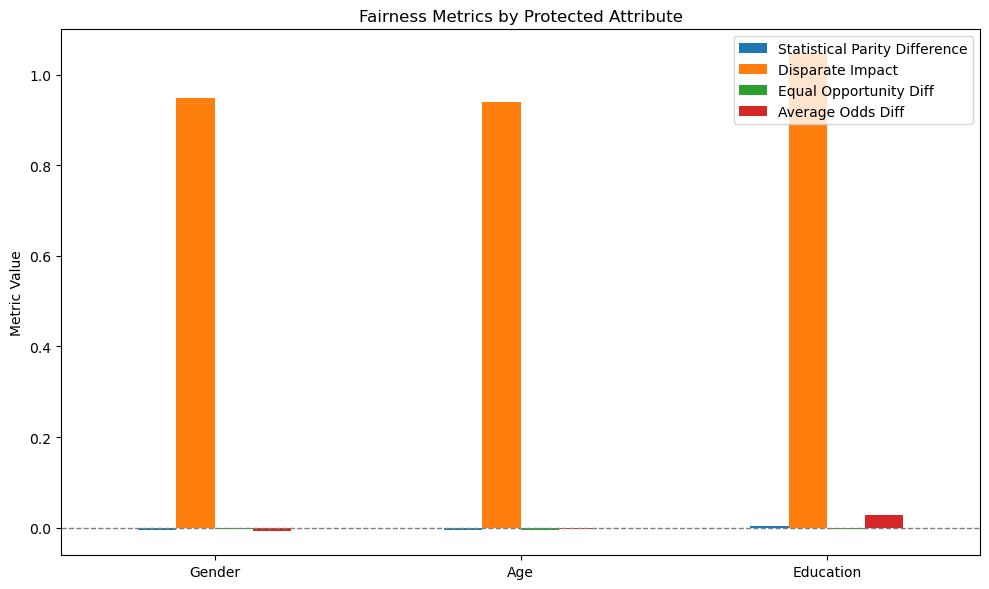

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fairness_results = {
    'Gender':     {'SPD': -0.0045, 'DI': 0.9497, 'EOD': -0.0033, 'AOD': -0.0084},
    'Age':        {'SPD': -0.0054, 'DI': 0.9396, 'EOD': -0.0062, 'AOD': -0.0032},
    'Education':  {'SPD':  0.0040, 'DI': 1.0478, 'EOD': -0.0035, 'AOD':  0.0280},
}


# Convert to DataFrame
df_fairness = pd.DataFrame(fairness_results).T
df_fairness = df_fairness.rename(columns={
    'SPD': 'Statistical Parity Difference',
    'DI': 'Disparate Impact',
    'EOD': 'Equal Opportunity Diff',
    'AOD': 'Average Odds Diff'
})

# Bar plot for all metrics
plt.figure(figsize=(10,6))
df_fairness.plot(kind='bar', ax=plt.gca())
plt.axhline(0, color='grey', linestyle='--', lw=1)
plt.title("Fairness Metrics by Protected Attribute")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fairness_metrics_barplot.png")
plt.show()


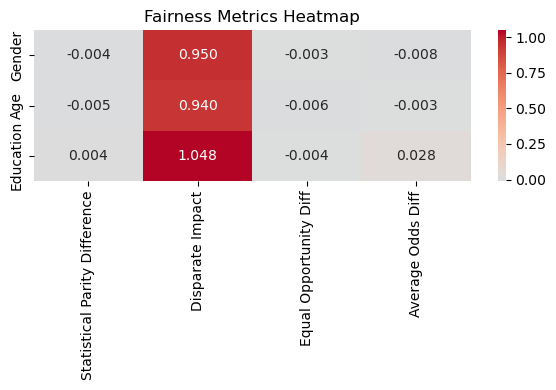

In [59]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_fairness, annot=True, cmap='coolwarm', center=0, fmt=".3f")
plt.title("Fairness Metrics Heatmap")
plt.tight_layout()
plt.savefig("fairness_metrics_heatmap.png")
plt.show()


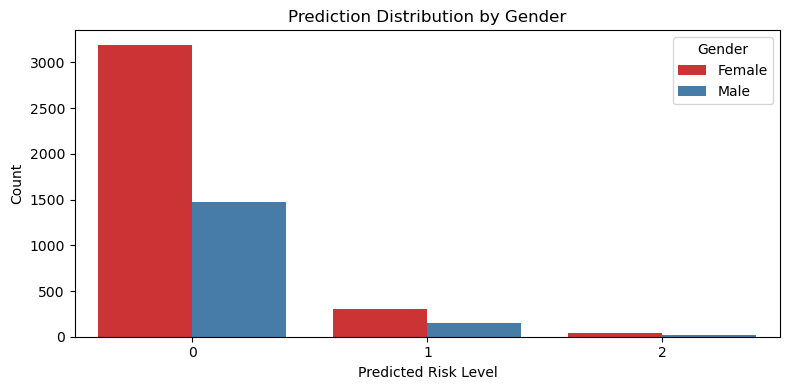

In [60]:
# df_test_fairness['Risk_Level'] = ground truth
# y_pred_threshold = model prediction, already aligned

df_test_fairness['y_pred'] = y_pred_threshold
group_labels = {1: "Male", 0: "Female"}

plt.figure(figsize=(8,4))
sns.countplot(
    data=df_test_fairness,
    x='y_pred',
    hue='Gender',
    palette='Set1',
    order=sorted(df_test_fairness['y_pred'].unique())
)
plt.xlabel("Predicted Risk Level")
plt.ylabel("Count")
plt.title("Prediction Distribution by Gender")
plt.legend(title='Gender', labels=[group_labels[i] for i in sorted(group_labels.keys())])
plt.tight_layout()
plt.savefig("pred_dist_by_gender.png")
plt.show()


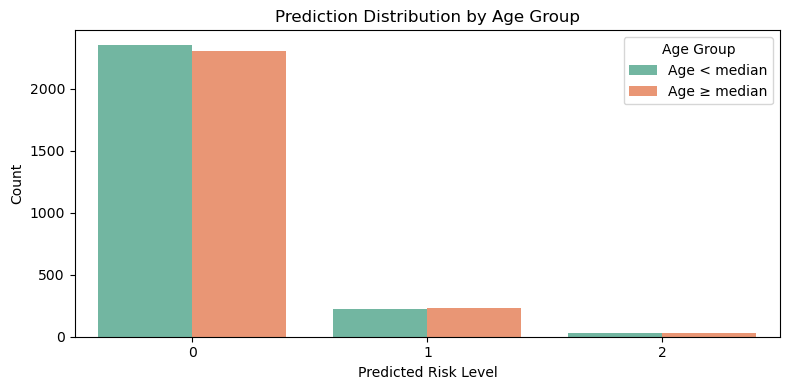

In [61]:
if 'Age_Privileged' in df_test_fairness.columns:
    age_labels = {1: "Age ≥ median", 0: "Age < median"}
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=df_test_fairness,
        x='y_pred',
        hue='Age_Privileged',
        palette='Set2',
        order=sorted(df_test_fairness['y_pred'].unique())
    )
    plt.xlabel("Predicted Risk Level")
    plt.ylabel("Count")
    plt.title("Prediction Distribution by Age Group")
    plt.legend(title='Age Group', labels=[age_labels[i] for i in sorted(age_labels.keys())])
    plt.tight_layout()
    plt.savefig("pred_dist_by_age.png")
    plt.show()


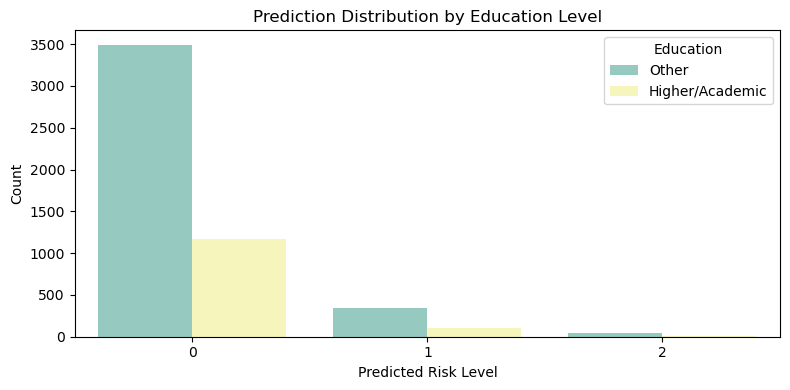

In [62]:
if 'Edu_Privileged' in df_test_fairness.columns:
    edu_labels = {1: "Higher/Academic", 0: "Other"}
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=df_test_fairness,
        x='y_pred',
        hue='Edu_Privileged',
        palette='Set3',
        order=sorted(df_test_fairness['y_pred'].unique())
    )
    plt.xlabel("Predicted Risk Level")
    plt.ylabel("Count")
    plt.title("Prediction Distribution by Education Level")
    plt.legend(title='Education', labels=[edu_labels[i] for i in sorted(edu_labels.keys())])
    plt.tight_layout()
    plt.savefig("pred_dist_by_education.png")
    plt.show()


C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


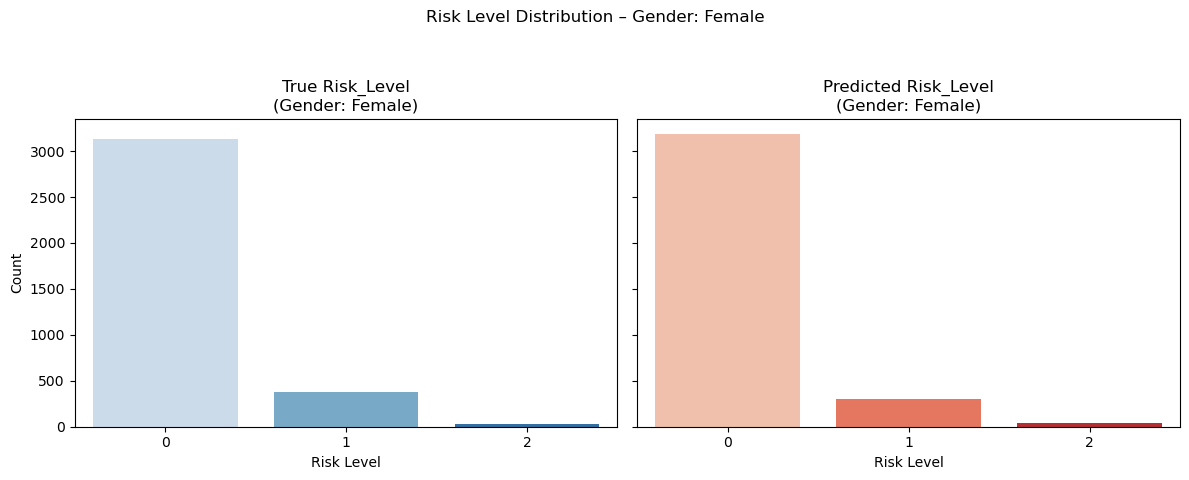

C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


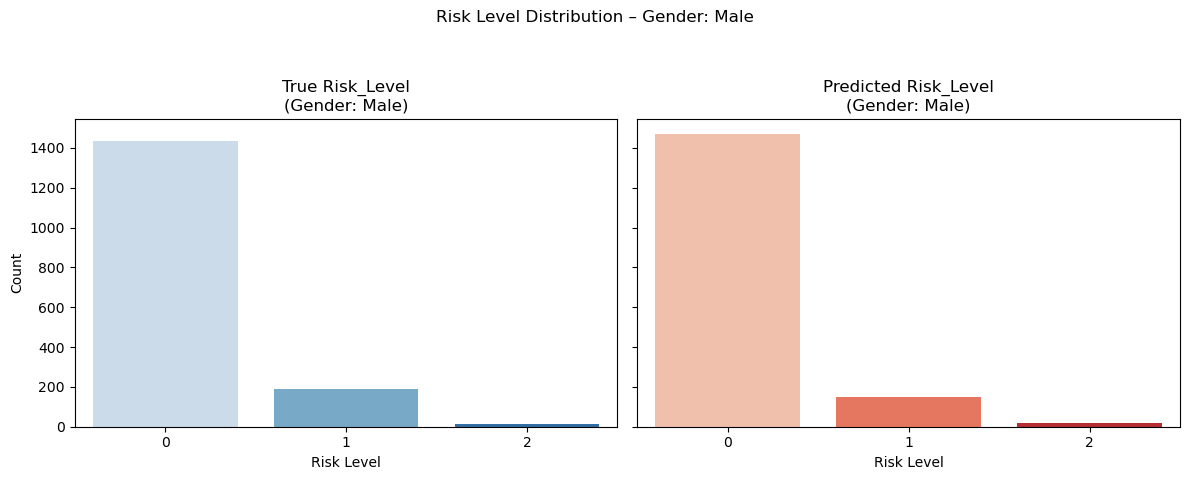

C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


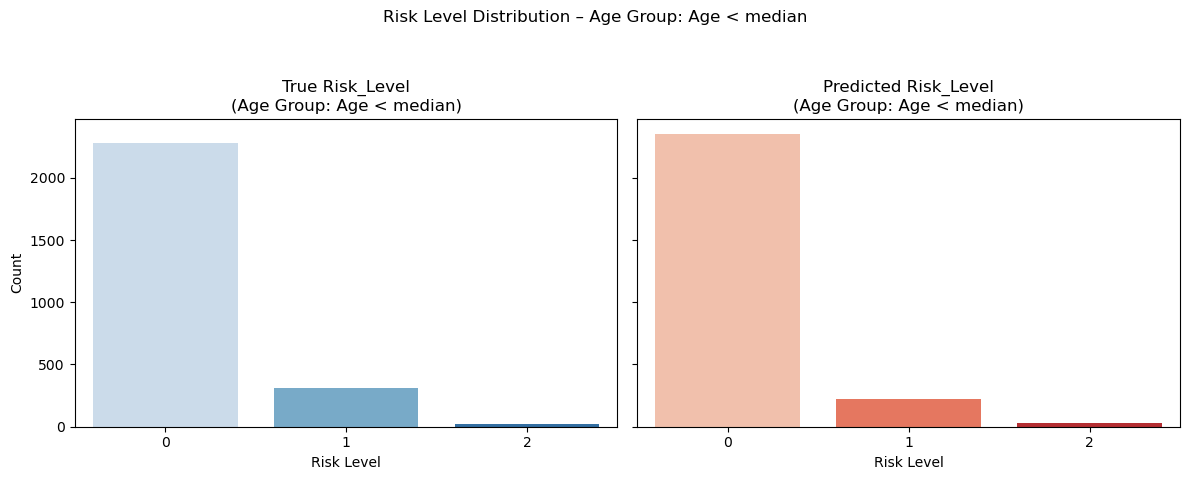

C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


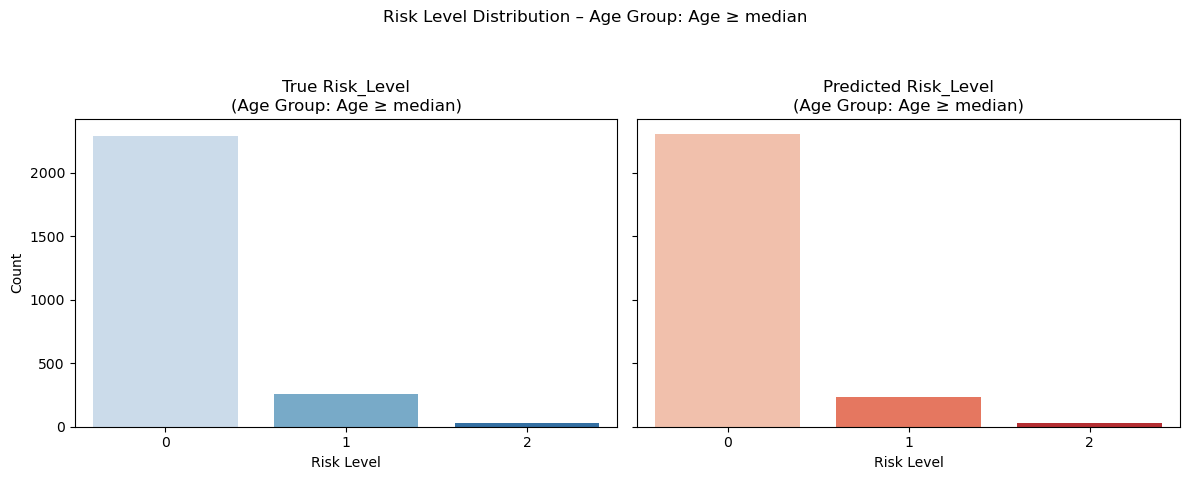

C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


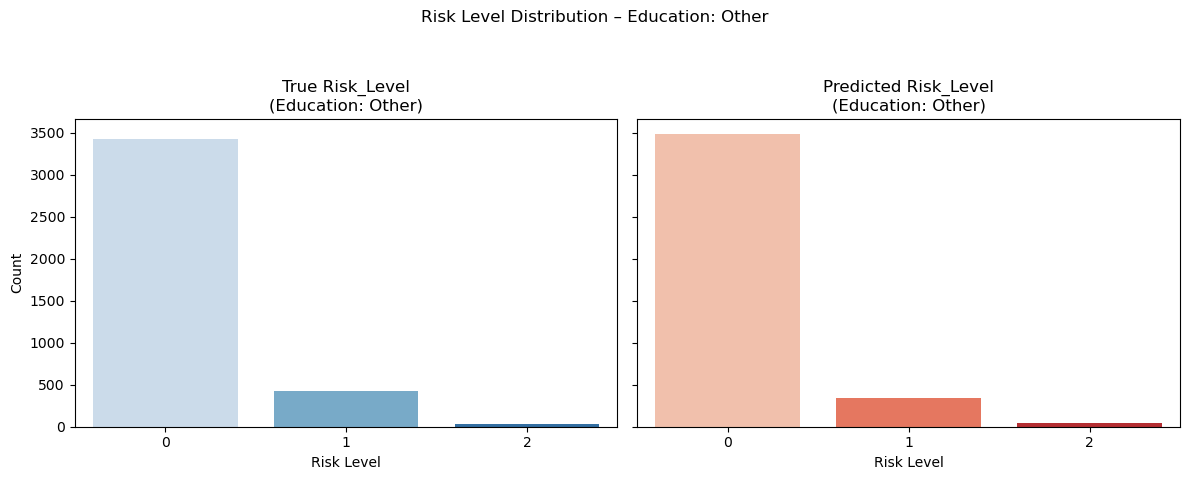

C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\1616382438.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


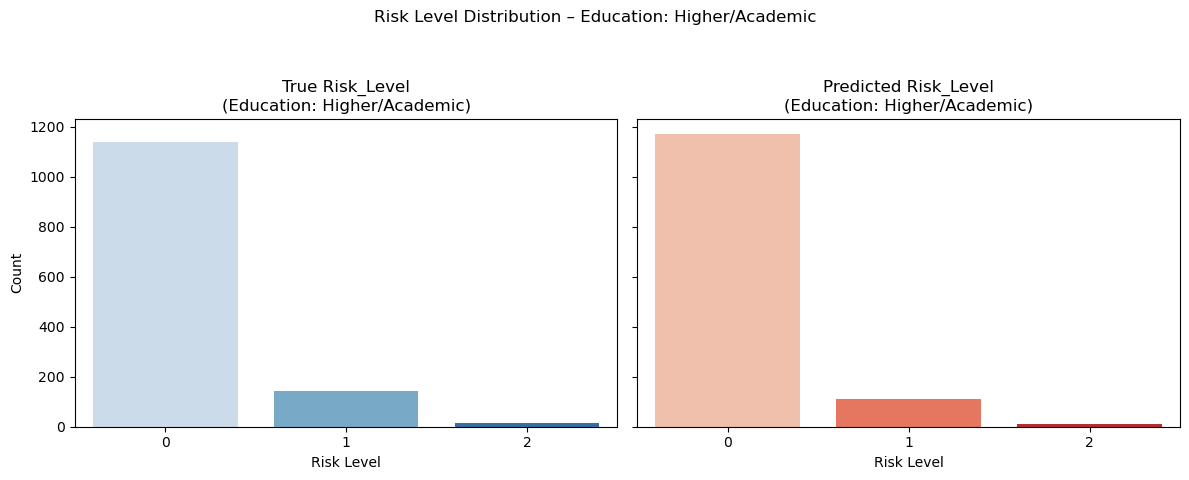

In [63]:

# df_test_fairness  Risk_Level, y_pred, Gender, Age_Privileged, Edu_Privileged
# y_pred_threshold = predicțiile aliniate cu fairness dataframe

df_test_fairness['y_pred'] = y_pred_threshold 

group_info = [
    ('Gender',      {1: "Male", 0: "Female"},             'Gender'),
    ('Age_Privileged', {1: "Age ≥ median", 0: "Age < median"}, 'Age Group'),
    ('Edu_Privileged', {1: "Higher/Academic", 0: "Other"}, 'Education')
]

for col, label_dict, group_title in group_info:
    if col not in df_test_fairness.columns:
        continue
    for val in sorted(df_test_fairness[col].unique()):
        group_label = label_dict.get(val, str(val))
        data_group = df_test_fairness[df_test_fairness[col] == val]
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        # Real
        sns.countplot(
            data=data_group,
            x='Risk_Level',
            order=sorted(data_group['Risk_Level'].unique()),
            ax=axes[0],
            palette='Blues'
        )
        axes[0].set_title(f"True Risk_Level\n({group_title}: {group_label})")
        axes[0].set_xlabel("Risk Level")
        axes[0].set_ylabel("Count")
        # Pred
        sns.countplot(
            data=data_group,
            x='y_pred',
            order=sorted(data_group['y_pred'].unique()),
            ax=axes[1],
            palette='Reds'
        )
        axes[1].set_title(f"Predicted Risk_Level\n({group_title}: {group_label})")
        axes[1].set_xlabel("Risk Level")
        axes[1].set_ylabel("")
        plt.suptitle(f"Risk Level Distribution – {group_title}: {group_label}")
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.savefig(f"comp_dist_{col}_{val}.png")
        plt.show()


##### Fairness Visualization Report


To assess and compare fairness across protected attributes, I generated a suite of visualizations using both true and predicted labels on the test set.

1. Risk Level Distribution by Protected Attribute

For each attribute (gender, age group, education level), I plotted side-by-side the true distribution of risk classes and the predicted distribution. This provides a direct visual check for bias or systematic errors in the model’s decisions.

2. Fairness Metrics Comparison

I computed and plotted four key fairness metrics for each attribute: Statistical Parity Difference (SPD), Disparate Impact (DI), Equal Opportunity Difference (EOD), and Average Odds Difference (AOD). Both bar plots and heatmaps were used to facilitate interpretation and comparison.

3. Prediction Distribution by Subgroup

To further understand model behavior, I plotted the distribution of predicted risk classes for each subgroup (e.g., Age < median vs Age ≥ median). These plots help reveal if certain groups are systematically assigned to higher or lower risk categories.

All visuals are attached below and included in the appendix.
(Poți adăuga aici imaginile sau trimite la un capitol/appendix)

In [65]:
import os


output_dir = "fairness_plots"
os.makedirs(output_dir, exist_ok=True)

# -------- SETTINGS --------
attributes = [
    ("Gender", {0: "Female", 1: "Male"}),
    ("Age_Privileged", {0: "Age < median", 1: "Age ≥ median"}),
    ("Edu_Privileged", {0: "Other", 1: "Higher/Academic"})
]
risk_labels = {0: "Good Client", 1: "Low Risk", 2: "High Risk"}

# ------------- DISTRIBUTION PLOTS REAL vs. PRED -------------
for attr, label_dict in attributes:
    for code, name in label_dict.items():
        mask = df_test_fairness[attr] == code
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.countplot(
            x="Risk_Level", 
            data=df_test_fairness[mask], 
            palette="Blues", 
            order=[0, 1, 2]
        )
        plt.title(f"True Risk_Level\n({attr}: {name})")
        plt.xlabel("Risk Level")
        plt.ylabel("Count")
        plt.subplot(1, 2, 2)
        sns.countplot(
            x=y_pred_threshold[mask], 
            palette="Reds", 
            order=[0, 1, 2]
        )
        plt.title(f"Predicted Risk_Level\n({attr}: {name})")
        plt.xlabel("Risk Level")
        plt.ylabel("")
        plt.suptitle(f"Risk Level Distribution – {attr}: {name}", y=1.02)
        plt.tight_layout()
        fname = os.path.join(output_dir, f"comp_dist_{attr}_{code}.png")
        plt.savefig(fname, dpi=120)
        plt.close()

# ---------------- FAIRNESS METRICS BARPLOT & HEATMAP -----------------
# Define your metrics from previous steps:
fairness_results = {
    "Gender":   [-0.0045, 0.95, -0.0033, -0.0084],  # replace with your exact values
    "Age":      [-0.0054, 0.94, -0.0062, -0.0032],
    "Education":[ 0.0040, 1.05, -0.0035,  0.0280]
}
metrics_names = [
    "Statistical Parity Difference",
    "Disparate Impact",
    "Equal Opportunity Diff",
    "Average Odds Diff"
]

# BARPLOT
plt.figure(figsize=(10, 6))
bar_width = 0.2
x = np.arange(len(fairness_results))
for i, m in enumerate(metrics_names):
    vals = [fairness_results[attr][i] for attr in fairness_results]
    plt.bar(x + i * bar_width, vals, width=bar_width, label=m)
plt.xticks(x + 1.5*bar_width, fairness_results.keys())
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.ylabel("Metric Value")
plt.title("Fairness Metrics by Protected Attribute")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fairness_metrics_barplot.png"), dpi=120)
plt.close()

# HEATMAP
metrics_matrix = np.array(list(fairness_results.values()))
plt.figure(figsize=(6, 4))
sns.heatmap(
    metrics_matrix, annot=True, fmt=".3f", cmap="Reds",
    yticklabels=list(fairness_results.keys()), 
    xticklabels=metrics_names
)
plt.title("Fairness Metrics Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "fairness_metrics_heatmap.png"), dpi=120)
plt.close()

# ------------ DISTRIBUTION BY GROUP --------------
# By Age group
plt.figure(figsize=(8, 4))
sns.countplot(
    x=y_pred_threshold, 
    hue=df_test_fairness["Age_Privileged"].map({0: "Age < median", 1: "Age ≥ median"}),
    order=[0, 1, 2]
)
plt.title("Prediction Distribution by Age Group")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Count")
plt.legend(title="Age Group")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pred_dist_by_age.png"), dpi=120)
plt.close()

# By Education group
plt.figure(figsize=(8, 4))
sns.countplot(
    x=y_pred_threshold,
    hue=df_test_fairness["Edu_Privileged"].map({0: "Other", 1: "Higher/Academic"}),
    order=[0, 1, 2]
)
plt.title("Prediction Distribution by Education Level")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Count")
plt.legend(title="Education")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pred_dist_by_education.png"), dpi=120)
plt.close()

print("All fairness plots saved in:", output_dir)


C:\Users\victo\AppData\Local\Temp\ipykernel_32596\2002219928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\2002219928.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\2002219928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\victo\AppData\Local\Temp\ipykernel_32596\2002219928.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

All fairness plots saved in: fairness_plots
